Saved: lc-pom/Interpolated_Director_Field/rotated_90_filament_r_0p7um.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_0_filament_r_0p7um.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_90_filament_r_1p0um.txt
Saved: lc-pom/Interpolated_Director_Field/rotated_0_filament_r_1p0um.txt


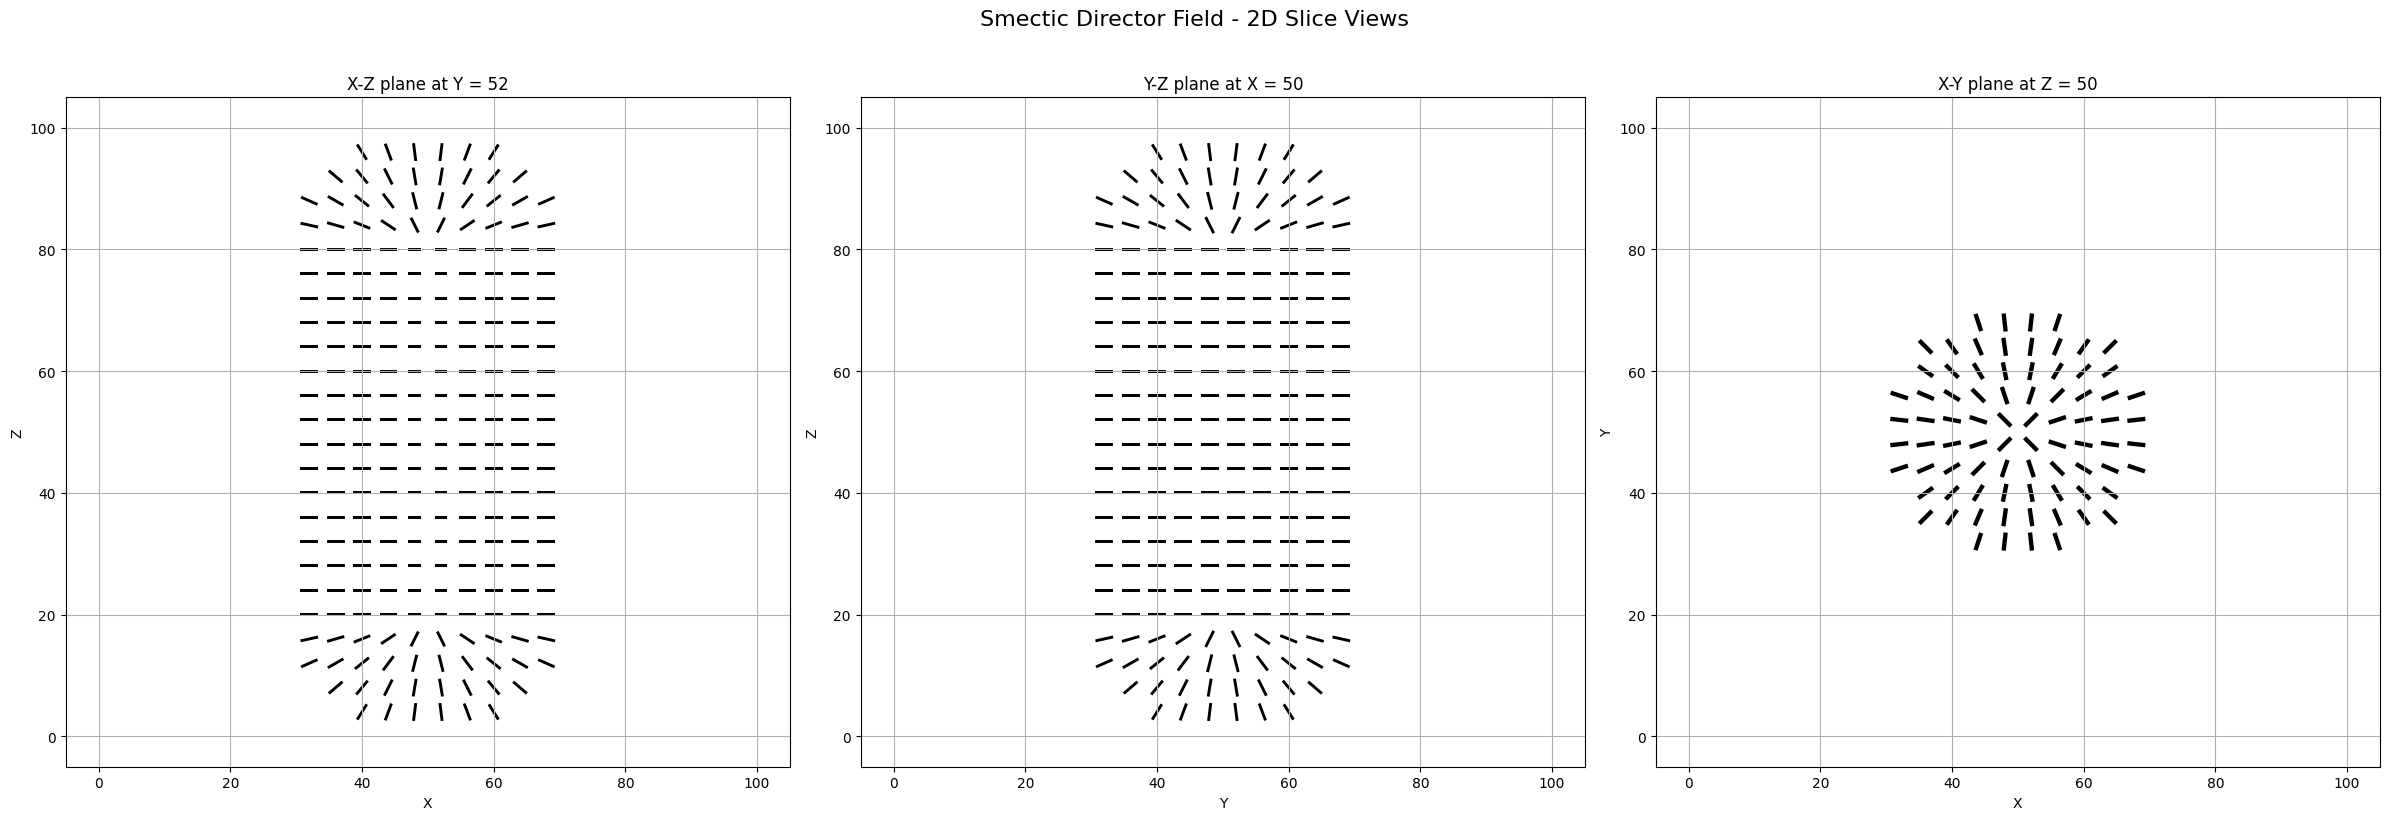

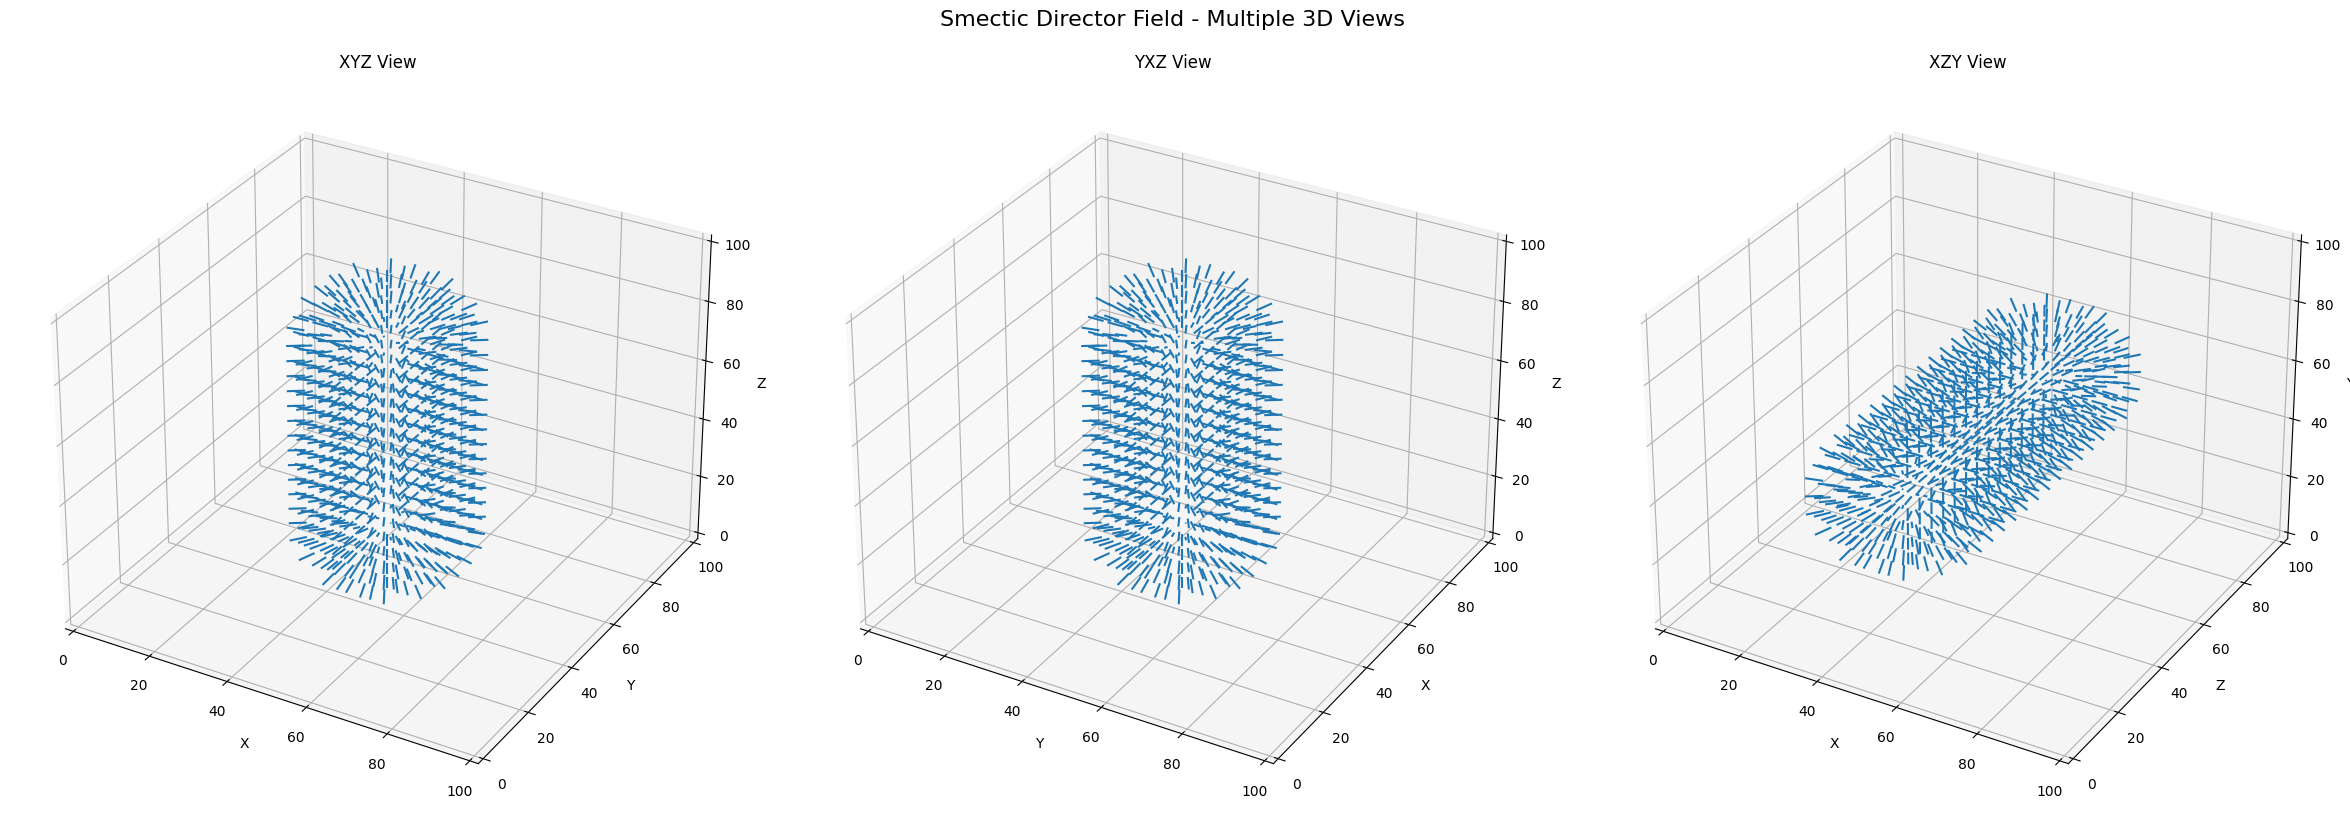

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform


def create_nematic_cylinder(X, Y, Z, Cx, Cy, Cz, r, h, axis_direction):
    """
    Create a nematic cylinder with arbitrary axis direction and spherical caps at both ends.
    
    Parameters:
        X, Y, Z: 3D arrays representing the grid of coordinates.
        Cx, Cy, Cz: Center of the cylinder.
        r: Radius of the cylinder.
        h: Height of the cylinder.
        axis_direction: Tuple or list representing the direction vector of the cylinder axis (ax, ay, az).
    
    Returns:
        returnX, returnY, returnZ: Arrays with the normalized vector components inside the cylinder and caps.
    """
    # Ensure coordinate grids use float64 for numerical precision
    X = X.astype(np.float64)
    Y = Y.astype(np.float64)
    Z = Z.astype(np.float64)

    # Normalize the axis direction to unit length
    axis_direction = np.array(axis_direction, dtype=np.float64)
    axis_direction = axis_direction / np.linalg.norm(axis_direction)

    # Vector from cylinder center to each grid point
    points = np.stack([X - Cx, Y - Cy, Z - Cz], axis=-1)

    # Projection of each point onto cylinder axis: axial coordinate
    projection = np.sum(points * axis_direction, axis=-1, keepdims=True)

    # Component perpendicular to axis: subtract axial projection
    perpendicular_vectors = points - projection * axis_direction

    # Radial distance from axis for each grid point
    distances = np.sqrt(np.sum(perpendicular_vectors**2, axis=-1))

    # Mask for points inside the cylindrical body (excluding spherical caps)
    mask_cylinder = (
        (distances <= r) &
        (projection[..., 0] <= h / 2) &
        (projection[..., 0] >= -h / 2)
    )

    # Prevent division by zero for interior points
    min_dist = 1e-6
    distances[mask_cylinder] = np.maximum(distances[mask_cylinder], min_dist)

    # Prepare output arrays for director components
    returnX = np.zeros_like(X)
    returnY = np.zeros_like(Y)
    returnZ = np.zeros_like(Z)

    # Normalize the perpendicular vectors inside the cylinder
    perp_norm = np.zeros_like(perpendicular_vectors)
    perp_norm[mask_cylinder] = (
        perpendicular_vectors[mask_cylinder] / distances[mask_cylinder, None]
    )

    # Assign to output for cylinder region
    returnX[mask_cylinder] = perp_norm[mask_cylinder, 0]
    returnY[mask_cylinder] = perp_norm[mask_cylinder, 1]
    returnZ[mask_cylinder] = perp_norm[mask_cylinder, 2]

    # Define centers for spherical caps at each end
    cap_top_center = np.array([Cx, Cy, Cz]) + (h / 2) * axis_direction
    cap_bottom_center = np.array([Cx, Cy, Cz]) - (h / 2) * axis_direction

    # Distance of each point from cap centers
    dist_top = np.sqrt(
        (X - cap_top_center[0])**2 +
        (Y - cap_top_center[1])**2 +
        (Z - cap_top_center[2])**2
    )
    dist_bottom = np.sqrt(
        (X - cap_bottom_center[0])**2 +
        (Y - cap_bottom_center[1])**2 +
        (Z - cap_bottom_center[2])**2
    )

    # Masks for points inside top and bottom spherical caps
    mask_top_cap = (dist_top <= r) & (projection[..., 0] > h / 2)
    mask_bottom_cap = (dist_bottom <= r) & (projection[..., 0] < -h / 2)

    # Radial director orientation in top cap
    returnX[mask_top_cap] = (X[mask_top_cap] - cap_top_center[0]) / dist_top[mask_top_cap]
    returnY[mask_top_cap] = (Y[mask_top_cap] - cap_top_center[1]) / dist_top[mask_top_cap]
    returnZ[mask_top_cap] = (Z[mask_top_cap] - cap_top_center[2]) / dist_top[mask_top_cap]

    # Radial director orientation in bottom cap
    returnX[mask_bottom_cap] = (X[mask_bottom_cap] - cap_bottom_center[0]) / dist_bottom[mask_bottom_cap]
    returnY[mask_bottom_cap] = (Y[mask_bottom_cap] - cap_bottom_center[1]) / dist_bottom[mask_bottom_cap]
    returnZ[mask_bottom_cap] = (Z[mask_bottom_cap] - cap_bottom_center[2]) / dist_bottom[mask_bottom_cap]

    return returnX, returnY, returnZ


def rotate_field(nx, ny, nz, rotation_matrix):
    """
    Rotate the 3D director field by a given rotation matrix.
    """
    # Inverse for affine transform
    inv_R = np.linalg.inv(rotation_matrix)
    # Center of the volume for offset calculation
    center = np.array(nx.shape) / 2

    def transform(arr):
        # Apply affine transform with inverse rotation and offset
        return affine_transform(
            arr,
            matrix=inv_R,
            offset=center - inv_R @ center,
            order=1,
            mode='nearest'
        )

    # Transform each component volume
    nx_t = transform(nx)
    ny_t = transform(ny)
    nz_t = transform(nz)

    # Stack and apply rotation to vector components
    stacked = np.stack((nx_t, ny_t, nz_t), axis=-1)
    rotated = stacked @ rotation_matrix.T
    return rotated[..., 0], rotated[..., 1], rotated[..., 2]


def export_directors(X, Y, Z, nx, ny, nz, dx, dy, dz, output_dir, prefix):
    # Compose header lines for grid dimensions and spacing
    header1 = f"{X.shape[0]} {Y.shape[1]} {Z.shape[2]} {dx:.2f} {dy:.2f} {dz:.2f}"
    header2 = f"0 {X.shape[0]-1} 0 {Y.shape[1]-1} 0 {Z.shape[2]-1}"
    # Stack data for saving or printing
    data = np.vstack([X.ravel(), Y.ravel(), Z.ravel(), nx.ravel(), ny.ravel(), nz.ravel()]).T
    path = os.path.join(output_dir, f"{prefix}.txt")
    # Print path (enable file writing here if desired)
    print(f"Saved: {path}")


def main():
    # Create a cubic coordinate grid
    L = 101
    X, Y, Z = np.meshgrid(np.arange(L), np.arange(L), np.arange(L), indexing='ij')

    # Cylinder geometry parameters
    Cx, Cy, Cz = 50, 50, 50
    radius = 20
    height = 60
    axis = (0, 0, 1)

    # Generate the director field for the cylinder
    nx, ny, nz = create_nematic_cylinder(X, Y, Z, Cx, Cy, Cz, radius, height, axis)

    # Export rotated fields for different filament sizes and angles
    r_e_values = [0.7, 1.0]
    angles = [90, 0]
    output_dir = "lc-pom/Interpolated_Director_Field"

    for r_e in r_e_values:
        # Determine spacing scale based on filament diameter
        spacing = r_e / radius
        dx = dy = dz = spacing * 1e6  # convert to micrometer-to-nanometer scale
        for angle in angles:
            theta = np.radians(angle)
            # Define rotation about x-axis
            Rx = np.array([
                [1, 0, 0],
                [0, np.cos(theta), -np.sin(theta)],
                [0, np.sin(theta),  np.cos(theta)]
            ])
            # Rotate and export
            nx_r, ny_r, nz_r = rotate_field(nx, ny, nz, Rx)
            prefix = f"rotated_{angle}_filament_r_{str(r_e).replace('.', 'p')}um"
            export_directors(X, Y, Z, nx_r, ny_r, nz_r, dx, dy, dz, output_dir, prefix)

    # Visualization parameters for quiver plots
    scale1 = scale2 = scale3 = 40
    width1 = width2 = 0.004
    width3 = 0.006
    headaxislength = headlength = 0
    headwidth = 1
    k1 = k2 = k3 = 4
    y_display = 52; x_display = 50; z_display = 50

    # Mask zero vectors to avoid plotting null arrows
    nx_p1, nz_p1 = nx.copy(), nz.copy()
    mask1 = (nx_p1 == 0) & (nz_p1 == 0)
    nx_p1[mask1] = nz_p1[mask1] = np.nan
    ny_p2, nz_p2 = ny.copy(), nz.copy()
    mask2 = (ny_p2 == 0) & (nz_p2 == 0)
    ny_p2[mask2] = nz_p2[mask2] = np.nan
    nx_p3, ny_p3 = nx.copy(), ny.copy()
    mask3 = (nx_p3 == 0) & (ny_p3 == 0)
    nx_p3[mask3] = ny_p3[mask3] = np.nan

    # 2D quiver plots for three orthogonal slices
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('Smectic Director Field - 2D Slice Views', fontsize=16, y=1.02)

    # X-Z plane slice at fixed Y index
    axes[0].quiver(
        X[::k1, y_display, ::k1], Z[::k1, y_display, ::k1],
        nx_p1[::k1, y_display, ::k1], nz_p1[::k1, y_display, ::k1],
        pivot='middle', scale=scale1, width=width1,
        headlength=headlength, headwidth=headwidth, headaxislength=headaxislength
    )
    axes[0].set_title(f'X-Z plane at Y = {y_display}')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Z'); axes[0].grid()

    # Y-Z plane slice at fixed X index
    axes[1].quiver(
        Y[x_display, ::k2, ::k2], Z[x_display, ::k2, ::k2],
        ny_p2[x_display, ::k2, ::k2], nz_p2[x_display, ::k2, ::k2],
        pivot='middle', scale=scale2, width=width2,
        headlength=headlength, headwidth=headwidth, headaxislength=headaxislength
    )
    axes[1].set_title(f'Y-Z plane at X = {x_display}')
    axes[1].set_xlabel('Y'); axes[1].set_ylabel('Z'); axes[1].grid()

    # X-Y plane slice at fixed Z index
    axes[2].quiver(
        X[::k3, ::k3, z_display], Y[::k3, ::k3, z_display],
        nx_p3[::k3, ::k3, z_display], ny_p3[::k3, ::k3, z_display],
        pivot='middle', scale=scale3, width=width3,
        headlength=headlength, headwidth=headwidth, headaxislength=headaxislength
    )
    axes[2].set_title(f'X-Y plane at Z = {z_display}')
    axes[2].set_xlabel('X'); axes[2].set_ylabel('Y'); axes[2].grid()

    plt.tight_layout()
    plt.show()

    # 3D quiver plots: three different viewing orientations
    s = 5  # sparsity for arrows in each dimension
    length = 4  # arrow length scaling
    arrow_length_ratio = 0  # disable automatic scaling of arrowheads

    fig = plt.figure(figsize=(24, 8))
    fig.suptitle('Smectic Director Field - Multiple 3D Views', fontsize=16, y=1.02)

    # First 3D view: XYZ axes order
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.quiver(
        X[::s, ::s, ::s], Y[::s, ::s, ::s], Z[::s, ::s, ::s],
        nx[::s, ::s, ::s], ny[::s, ::s, ::s], nz[::s, ::s, ::s],
        length=length, arrow_length_ratio=arrow_length_ratio
    )
    ax1.set_title('XYZ View'); ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_xlim([0, L-1]); ax1.set_ylim([0, L-1]); ax1.set_zlim([0, L-1])

    # Second 3D view: YXZ axes order for alternate perspective
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.quiver(
        Y[::s, ::s, ::s], X[::s, ::s, ::s], Z[::s, ::s, ::s],
        ny[::s, ::s, ::s], nx[::s, ::s, ::s], nz[::s, ::s, ::s],
        length=length, arrow_length_ratio=arrow_length_ratio
    )
    ax2.set_title('YXZ View'); ax2.set_xlabel('Y'); ax2.set_ylabel('X'); ax2.set_zlabel('Z')
    ax2.set_xlim([0, L-1]); ax2.set_ylim([0, L-1]); ax2.set_zlim([0, L-1])

    # Third 3D view: XZY axes order for another angle
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.quiver(
        X[::s, ::s, ::s], Z[::s, ::s, ::s], Y[::s, ::s, ::s],
        nx[::s, ::s, ::s], nz[::s, ::s, ::s], ny[::s, ::s, ::s],
        length=length, arrow_length_ratio=arrow_length_ratio
    )
    ax3.set_title('XZY View'); ax3.set_xlabel('X'); ax3.set_ylabel('Z'); ax3.set_zlabel('Y')
    ax3.set_xlim([0, L-1]); ax3.set_ylim([0, L-1]); ax3.set_zlim([0, L-1])

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()